<a href="https://colab.research.google.com/github/Ahmed-25800/Ai-Bootcamp/blob/main/Copy_of_1_Image_Classification_with_CNN_Pytorch_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 03
### 1.Convolution Neural Networks
### 2.Convolutions, Pooling, Activation functions, Dropout
### 3.Training, Predictions
### 4.VGG Architecture
### 4.Pretained CNN weights from Imagenet Data(VGG16)

In [ ]:
import torch
import torchvision
print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Data Cifar-10

In [ ]:
import os
import tarfile
from torchvision.datasets.utils import download_url

In [ ]:
# Dowload the dataset
dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
download_url(dataset_url, '.')

# Extract from archive
with tarfile.open('./cifar10.tgz', 'r:gz') as tar:
    tar.extractall(path='./data')

100%|██████████| 135M/135M [00:09<00:00, 14.6MB/s]
/tmp/ipykernel_1257/1640521235.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='./data')


In [ ]:
data_dir = './data/cifar10'

print(os.listdir(data_dir))               # to check directories inside data_dir

classes = os.listdir(data_dir + "/test")   # to check directories inside train directory
print(classes)

airplane_files = os.listdir(data_dir + "/test/airplane")

print("No. of training examples for airplanes :", len(airplane_files))

['train', 'test']
['automobile', 'truck', 'bird', 'deer', 'horse', 'ship', 'airplane', 'cat', 'dog', 'frog']
No. of training examples for airplanes : 1000


In [ ]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

In [ ]:
dataset = ImageFolder(data_dir + "/train", transform=ToTensor())
dataset

Dataset ImageFolder
    Number of datapoints: 50000
    Root location: ./data/cifar10/train
    StandardTransform
Transform: ToTensor()

In [ ]:
len(dataset)

image, label = dataset[40000]
print("image shape:",image.shape, "Label :", label)

image shape: torch.Size([3, 32, 32]) Label : 8


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

matplotlib.rcParams['figure.facecolor'] = '#ffffff'

In [ ]:
def show_image(img, label):
  Label = dataset.classes[label]
  print("Label :", Label, "[" + str(label) + "]")

  image = img.permute(1,2,0)
  plt.imshow(image)

Label : automobile [1]


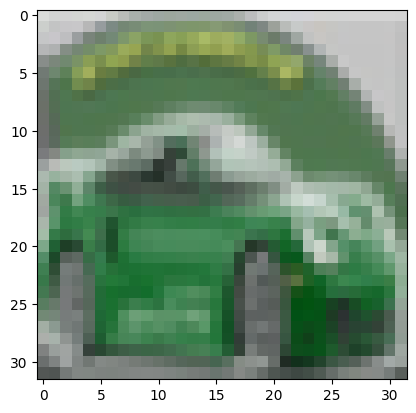

In [ ]:
show_image(*dataset[9000])

In [ ]:
from torch.utils.data import random_split

In [ ]:
validation_size = 5000

training_size = len(dataset) - validation_size

train_dataset, valid_dataset = random_split(dataset, [training_size, validation_size])

print("Training size :", len(train_dataset))
print("Validation size :", len(valid_dataset))

Training size : 45000
Validation size : 5000


In [ ]:
from torch.utils.data.dataloader import DataLoader

batch_size=64

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size, shuffle=True, num_workers=2, pin_memory=True)

valid_dataloader = DataLoader(valid_dataset, batch_size, num_workers=2, pin_memory=True)

# Data Visualizing

In [ ]:
from torchvision.utils import make_grid

In [ ]:
def show_batch(data_loader):

  for images, labels in data_loader:

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.set_xticks([]); ax.set_yticks([]);

    ax.imshow(make_grid(images, nrow=16).permute(1,2,0))     # as in tensor the order is C x W x H, so to show image we need order of W x H X C

    break


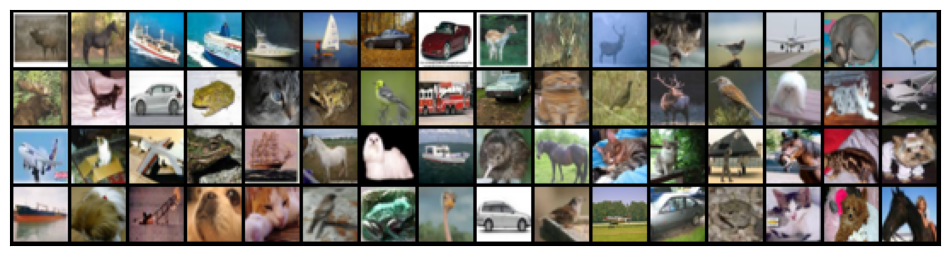

In [ ]:
show_batch(train_dataloader)

# CNN Models

In [ ]:
class CIFAR10Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=(3,3), stride=1, padding=1)
        self.act1 = nn.ReLU()

        self.conv2 = nn.Conv2d(32, 32, kernel_size=(3,3), stride=1, padding=1)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))

        self.flat = nn.Flatten()

        self.fc3 = nn.Linear(8192, 512)
        self.act3 = nn.ReLU()
        self.drop3 = nn.Dropout(0.5)

        self.fc4 = nn.Linear(512, 10)

    def forward(self, x):
        # input 3x32x32, output 32x32x32
        x = self.act1(self.conv1(x))
        # input 32x32x32, output 32x32x32
        x = self.act2(self.conv2(x))
        # input 32x32x32, output 32x16x16
        x = self.pool2(x)
        # input 32x16x16, output 8192
        x = self.flat(x)
        # input 8192, output 512
        x = self.act3(self.fc3(x))
        x = self.drop3(x)
        # input 512, output 10
        x = self.fc4(x)
        return x

model = CIFAR10Model().to(device)

In [ ]:
#VGG16

In [ ]:
import torch
import torch.nn as nn
class VGG16(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 3
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 4
        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        # Block 5
        self.block5 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.flatten = nn.Flatten()
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes)
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.block5(x)

        x = self.flatten(x)
        x = self.classifier(x)
        return x
vgg166=VGG16()
print(vgg166)

VGG16(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): 

# Training

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
epochs = 10

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        # print(labels.size(0))
        total += labels.size(0)#(1,100)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_dataloader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ===== VALIDATION =====
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in valid_dataloader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(valid_dataloader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.3f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Val Loss:: { val_loss:.2f} "
          f"Val Acc: {val_acc:.2f}%")

Epoch [1/10] Train Loss: 1.542 Train Acc: 44.13% Val Loss:: 1.27 Val Acc: 54.60%
Epoch [2/10] Train Loss: 1.185 Train Acc: 58.09% Val Loss:: 1.07 Val Acc: 61.10%
Epoch [3/10] Train Loss: 1.026 Train Acc: 63.76% Val Loss:: 1.01 Val Acc: 63.78%
Epoch [4/10] Train Loss: 0.917 Train Acc: 67.56% Val Loss:: 0.94 Val Acc: 66.36%
Epoch [5/10] Train Loss: 0.826 Train Acc: 70.83% Val Loss:: 0.94 Val Acc: 66.98%
Epoch [6/10] Train Loss: 0.755 Train Acc: 73.54% Val Loss:: 0.95 Val Acc: 66.50%
Epoch [7/10] Train Loss: 0.679 Train Acc: 75.94% Val Loss:: 0.91 Val Acc: 68.64%
Epoch [8/10] Train Loss: 0.614 Train Acc: 78.25% Val Loss:: 0.91 Val Acc: 69.06%
Epoch [9/10] Train Loss: 0.546 Train Acc: 80.68% Val Loss:: 0.95 Val Acc: 68.36%
Epoch [10/10] Train Loss: 0.488 Train Acc: 82.53% Val Loss:: 0.96 Val Acc: 69.48%


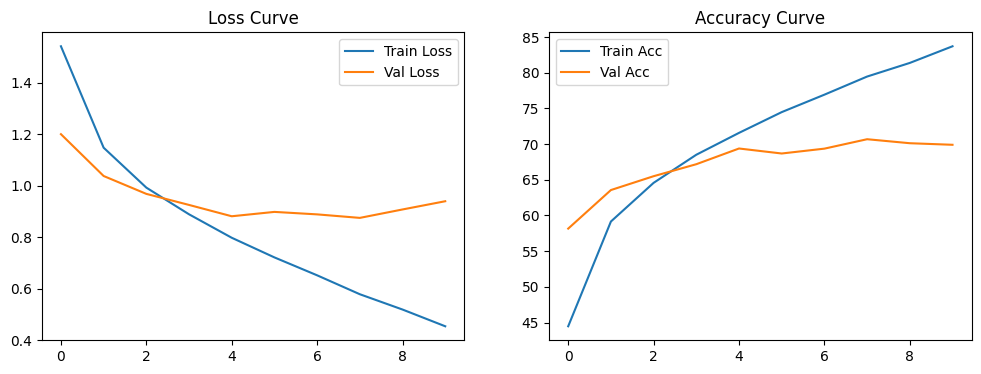

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

In [ ]:
torch.save(model.state_dict(), "cifar10model.pth")
print("Model saved!")

Model saved!


In [ ]:
model.state_dict()

OrderedDict([('conv1.weight',
              tensor([[[[-0.2152, -0.0647, -0.0018],
                        [ 0.1441,  0.0232, -0.0640],
                        [ 0.1745,  0.0491, -0.0542]],
              
                       [[-0.1732,  0.1080,  0.2309],
                        [ 0.1874, -0.0182,  0.1633],
                        [ 0.1455, -0.0960, -0.1610]],
              
                       [[-0.2892, -0.1777,  0.1502],
                        [-0.0194, -0.2479, -0.1262],
                        [ 0.1210,  0.0228, -0.0753]]],
              
              
                      [[[-0.0518,  0.1885,  0.2981],
                        [-0.1056, -0.2498, -0.0265],
                        [ 0.0354, -0.1027, -0.1888]],
              
                       [[-0.0161,  0.2106,  0.0808],
                        [-0.0423, -0.2738,  0.0538],
                        [-0.0629, -0.0430,  0.1244]],
              
                       [[ 0.2437,  0.0244,  0.1578],
                        [-

In [ ]:
test_dataset = ImageFolder(data_dir+'/test', transform=ToTensor())
testloader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

<Figure size 800x800 with 0 Axes>

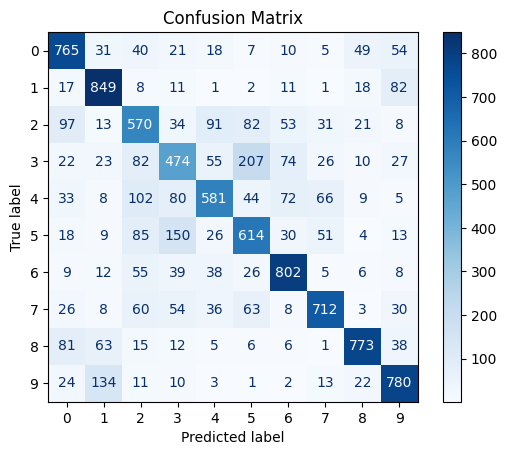

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

# CIFAR-10 class names
class_names = classes

report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4
)

print("📊 Classification Report:\n")
print(report)

📊 Classification Report:

              precision    recall  f1-score   support

  automobile     0.7005    0.7650    0.7314      1000
       truck     0.7383    0.8490    0.7898      1000
        bird     0.5545    0.5700    0.5621      1000
        deer     0.5356    0.4740    0.5029      1000
       horse     0.6803    0.5810    0.6268      1000
        ship     0.5837    0.6140    0.5984      1000
    airplane     0.7509    0.8020    0.7756      1000
         cat     0.7816    0.7120    0.7452      1000
         dog     0.8448    0.7730    0.8073      1000
        frog     0.7464    0.7800    0.7628      1000

    accuracy                         0.6920     10000
   macro avg     0.6917    0.6920    0.6902     10000
weighted avg     0.6917    0.6920    0.6902     10000



In [ ]:
# classes = trainset.classes

mis_images = []
mis_preds = []
mis_labels = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(images)):
            if preds[i] != labels[i]:
                mis_images.append(images[i].cpu())
                mis_preds.append(preds[i].cpu())
                mis_labels.append(labels[i].cpu())

            if len(mis_images) >= 16:
                break
        if len(mis_images) >= 16:
            break

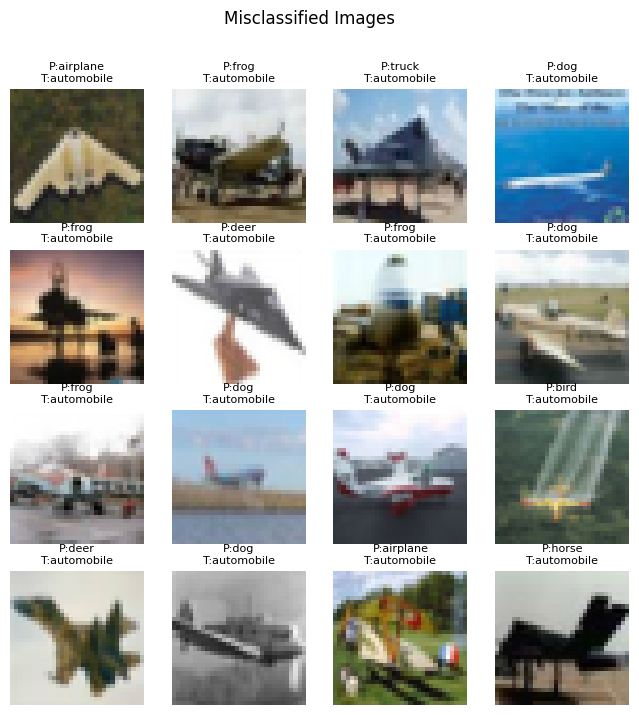

In [ ]:
fig, ax = plt.subplots(4,4, figsize=(8,8))

for i in range(16):
    r, c = i//4, i%4
    img = mis_images[i].permute(1,2,0)

    ax[r][c].imshow(img)
    ax[r][c].set_title(
        f"P:{classes[mis_preds[i]]}\nT:{classes[mis_labels[i]]}",
        fontsize=8
    )
    ax[r][c].axis("off")

plt.suptitle("Misclassified Images")
plt.show()

In [ ]:
model.load_state_dict(torch.load("cifar10model.pth"))

<All keys matched successfully>

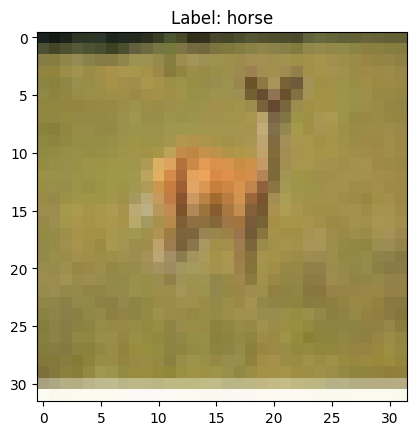

In [ ]:
img, label = train_dataset[7]
#img = img * 0.5 + 0.5
plt.imshow(np.transpose(img.numpy(), (1,2,0)))
plt.title(f"Label: {classes[label]}")
plt.show()

# 1. Identify Problems In Model building and Training
# 2. Train the model with best approach you can understand


# Pre-trained CNN Models(ImageNet Data)
### VGG16

In [ ]:
import torch
import torch.nn.functional as F
from torchvision import models, transforms
from PIL import Image
import json
import urllib.request

# 1 Load pretrained VGG16
model = models.vgg16(pretrained=True)
model.eval()

# 2 Preprocessing (ImageNet standard)
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# 3 Load image
img = Image.open("aero.jfif").convert("RGB")
input_tensor = preprocess(img)
input_batch = input_tensor.unsqueeze(0)

# 4 Inference
with torch.no_grad():
    outputs = model(input_batch)
    probabilities = F.softmax(outputs, dim=1)


# 5 Load labels
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
class_idx = urllib.request.urlopen(url).read().decode("utf-8").splitlines()
print(class_idx)

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead', 'electric ray', 'stingray', 'cock', 'hen', 'ostrich', 'brambling', 'goldfinch', 'house finch', 'junco', 'indigo bunting', 'robin', 'bulbul', 'jay', 'magpie', 'chickadee', 'water ouzel', 'kite', 'bald eagle', 'vulture', 'great grey owl', 'European fire salamander', 'common newt', 'eft', 'spotted salamander', 'axolotl', 'bullfrog', 'tree frog', 'tailed frog', 'loggerhead', 'leatherback turtle', 'mud turtle', 'terrapin', 'box turtle', 'banded gecko', 'common iguana', 'American chameleon', 'whiptail', 'agama', 'frilled lizard', 'alligator lizard', 'Gila monster', 'green lizard', 'African chameleon', 'Komodo dragon', 'African crocodile', 'American alligator', 'triceratops', 'thunder snake', 'ringneck snake', 'hognose snake', 'green snake', 'king snake', 'garter snake', 'water snake', 'vine snake', 'night snake', 'boa constrictor', 'rock python', 'Indian cobra', 'green mamba', 'sea snake', 'horned viper', 'diamondback', 

In [ ]:

# 6 Top 3 Predictions
top3_prob, top3_catid = torch.topk(probabilities, 3)
print("Predictions:")

for i in range(top3_prob.size(1)):
    print(f"{class_idx[top3_catid[0][i]]} : {top3_prob[0][i].item():.4f}")

Predictions:
airliner : 0.8779
warplane : 0.0881
projectile : 0.0147


In [ ]:
class_idx[0]

In [ ]:
print(model)

In [ ]:
from torchinfo import summary
summary(model)